# ***Enhancing Fraud Detection using Synthetic Data (CTGAN)***

**Project Type : Healthcare / Classification**

**Project Prepared By : Pranav Thakur**

**Domain : AIML**

# **Project Summary**

This project develops a machine learning–based system to detect fraudulent financial transactions. A Random Forest Classifier is trained on transaction data to classify each transaction as either fraudulent or legitimate.

An interactive Streamlit web application is built to allow users to input transaction features and receive real-time predictions along with a fraud probability score.

# **Problem Statement**

With the rapid growth of digital payments, fraudulent transactions have increased significantly, leading to major financial losses for individuals and financial institutions.

Traditional rule-based systems:

* Are slow and inflexible
* Can be bypassed easily
* Fail to capture complex patterns

Therefore, there is a need for an intelligent system that can:

* Detect hidden patterns in transaction data
* Provide fast and accurate predictions
* Operate in real-time environments

# **Importing Libraries**

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score , roc_curve


# **Dataset Loading**

In [2]:
df = pd.read_csv("creditcard.csv")
# Copy dataset
df_clean = df.copy()

# **Dataset First Look**

In [3]:
print("First 5 Rows:\n")
df_clean.head()

First 5 Rows:



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# **Dataset Rows And Columns**

In [4]:
print("Rows & Columns:",
df_clean.shape)

Rows & Columns: (284807, 31)


# **Dataset Information**

In [5]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

# **Statistical Summary**

In [6]:
df_clean.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


The dataset is well-preprocessed with normalized features , no missing values, and a wide range of values indicating strong variability useful for fraud detection models.

# **Unique Values**

In [7]:
df_clean.nunique()

,0
Time,124592
V1,275663
V2,275663
V3,275663
V4,275663
V5,275663
V6,275663
V7,275663
V8,275663
V9,275663


# **Duplicate Values**

In [8]:
# Duplicate Rows
df.duplicated().sum()
df[df.duplicated()]

# Duplivate Columns
df.columns.duplicated().sum()

print("Duplicates:", df_clean.duplicated().sum())

Duplicates: 1081


# **Missing Values**

In [9]:
df_clean.isnull().sum()
print("\nMissing Values:\n", df_clean.isnull().sum())


Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


# **Data Wrangling**

In [10]:
# Remove duplicates
df_clean = df_clean.drop_duplicates()

print("Duplicates:", df_clean.duplicated().sum())

Duplicates: 0


**Feature Scaling**

In [11]:
scaler = StandardScaler()

df_clean['scaled_amount'] = scaler.fit_transform(df_clean[['Amount']])
df_clean['scaled_time'] = scaler.fit_transform(df_clean[['Time']])

df_clean = df_clean.drop(['Amount', 'Time'], axis=1)

**Data Formatting**

In [12]:
scaled_cols = ['scaled_time', 'scaled_amount']
other_cols = [col for col in df_clean.columns if col not in scaled_cols + ['Class']]

df_clean = df_clean[scaled_cols + other_cols + ['Class']]

**Class Imbalance Check**

In [13]:
print(df_clean['Class'].value_counts())
print(df_clean['Class'].value_counts(normalize=True)*100)

Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


**Data Splitting**

In [14]:
df_clean = df_clean.dropna(subset=['Class'])
X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# **Exploratory Data Analysis (EDA)**

# **1️⃣ Class Distribution**

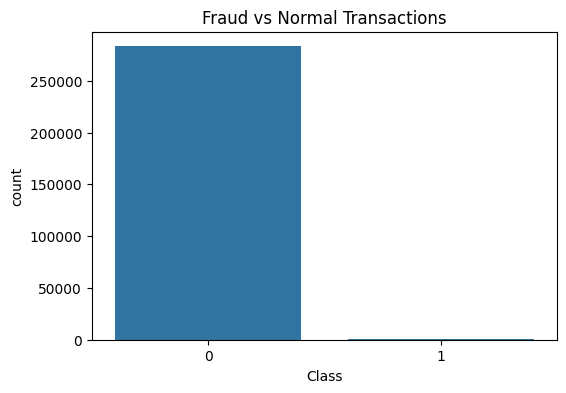

Class
0    283253
1       473
Name: count, dtype: int64


In [15]:

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df_clean)
plt.title("Fraud vs Normal Transactions")
plt.show()

print(df_clean['Class'].value_counts())

**Why this chart?**

To understand whether the dataset is balanced or imbalanced between fraud and legitimate transactions.

**What does it show?**

It shows the number of transactions belonging to:

* Class 0 → Legitimate
* Class 1 → Fraudulent

**Insight:**

The dataset is heavily imbalanced, with significantly more legitimate transactions than fraud cases.

**Analysis:**

This imbalance can lead to biased model predictions. Accuracy alone is not reliable, so metrics like precision, recall, and F1-score are more important. Handling imbalance is crucial for better fraud detection.

# **2️⃣ Percentage Distribution**

In [16]:
print(df_clean['Class'].value_counts(normalize=True)*100)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


# **3️⃣ Transaction Amount Distribution**

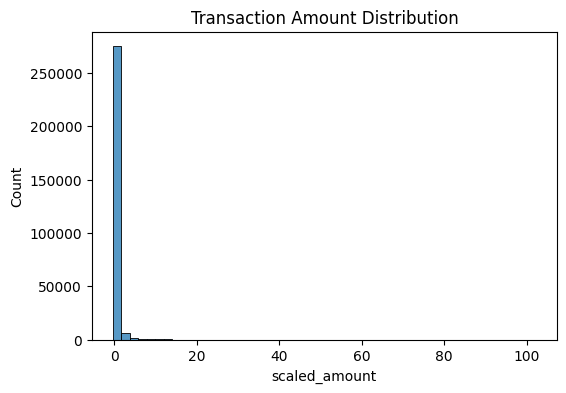

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean['scaled_amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

**Why this chart?**

To understand how transaction amounts are distributed across the dataset.

**What does it show?**

It shows the frequency of different transaction amounts.

**Insight:**

Most transactions are of low value, while high-value transactions are rare.

**Analysis:**

The distribution is skewed, indicating the need for scaling. Fraud is not limited to high amounts, so amount alone is not a strong indicator.

* Amount is skewed → scaling required

* Fraud can happen at any amount → not reliable alone

# **4️⃣ Fraud vs Amount**

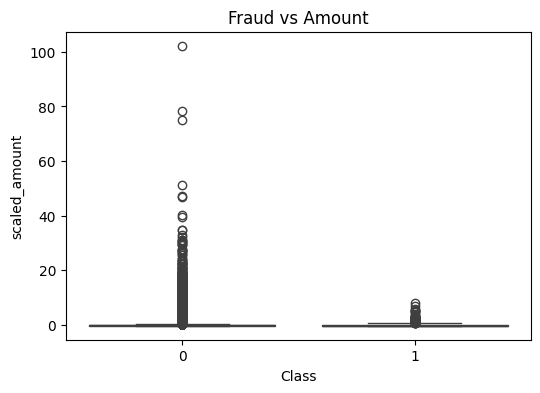

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='scaled_amount', data=df_clean)
plt.title("Fraud vs Amount")
plt.show()

**Why this chart?**

To compare transaction amounts between fraud and legitimate transactions.

**What does it show?**

Boxplot showing distribution of scaled_amount for:

* Class 0 → Legit
* Class 1 → Fraud

**Insight:**

Fraud transactions exist across a wide range of values, but most data points are concentrated near lower values. Legit transactions show more spread with extreme outliers.

**Analysis:**

There is no clear separation between fraud and legit transactions based only on amount.
Hence, amount alone is not sufficient for detecting fraud and must be combined with other features.

# **5️⃣ Correlation Heatmap**

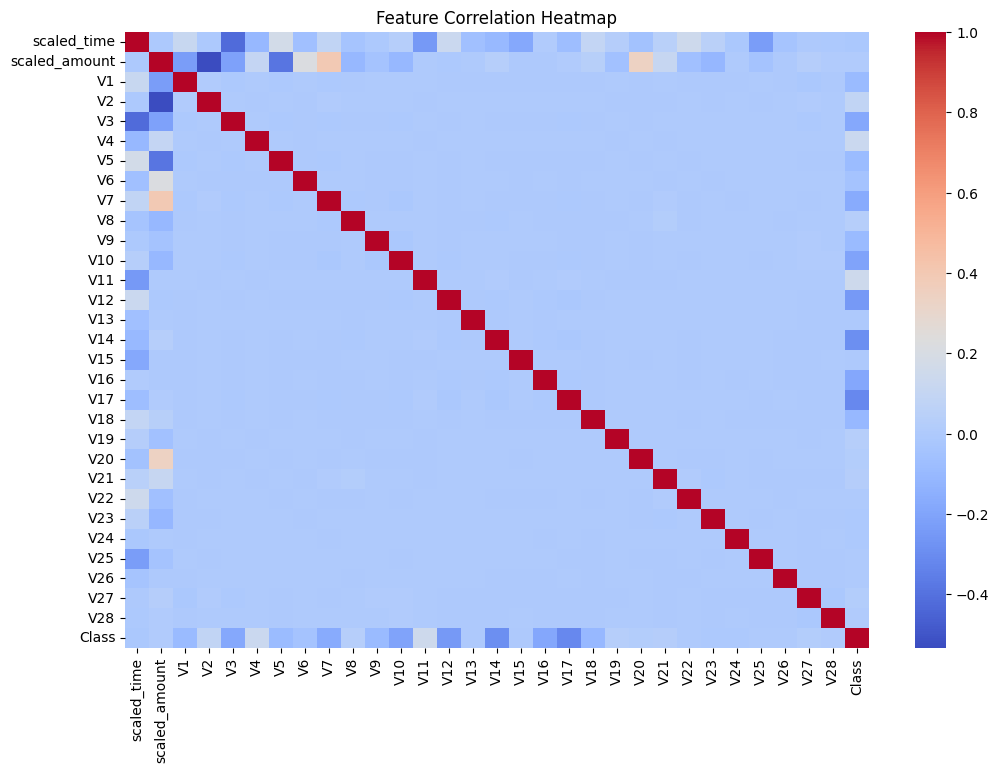

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

**Why this chart ?**

To identify relationships between different features.

**What does this show ?**

Heatmap showing correlation values between:

* Scaled_time
* Scaled_amount
* V1 to V28

**Insight:**

Most features show very low correlation with each other.

**Analysis:**

Low correlation is beneficial because:

* It reduces redundancy
* Improves model performance
* Indicates independent feature contribution

This supports the use of models like Random Forest.

# 6️⃣ Time vs Fraud


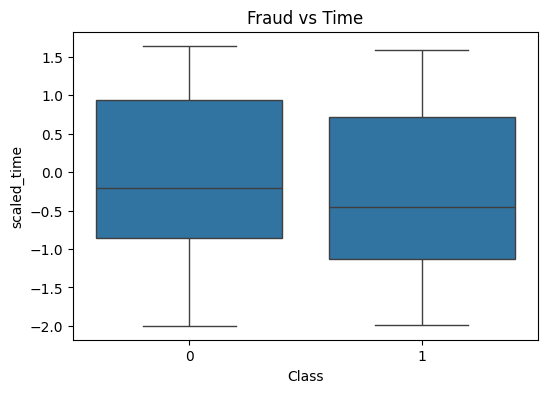

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='scaled_time', data=df_clean)
plt.title("Fraud vs Time")
plt.show()

**Why this chart ?**

To check if fraud transactions occur at specific time patterns.

**What does this show ?**

Boxplot comparing scaled_time for:

Fraud vs Legit

**Insight:**

Both fraud and legit transactions have similar distribution over time.

**Analysis:**

Time does not provide strong separation between classes.
It is a weak feature alone, but may still help when combined with other features.

# **7️⃣ Fraud vs Normal (Distribution Curve)**

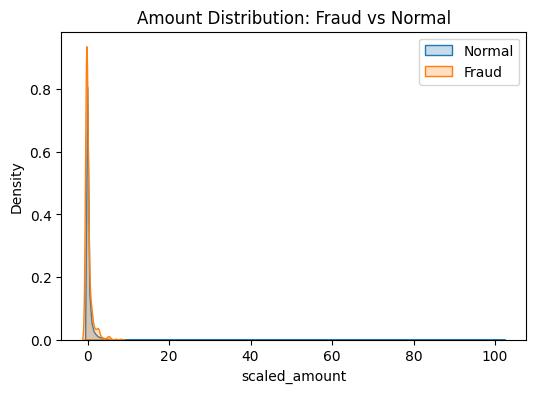

In [21]:
plt.figure(figsize=(6,4))
sns.kdeplot(df_clean[df_clean['Class']==0]['scaled_amount'], label='Normal', fill=True)
sns.kdeplot(df_clean[df_clean['Class']==1]['scaled_amount'], label='Fraud', fill=True)
plt.title("Amount Distribution: Fraud vs Normal")
plt.legend()
plt.show()

**Why this chart ?**

To compare probability distribution of transaction amounts.

**What does this show ?**

KDE plot comparing:

* Normal transactions
* Fraud transactions

**Insight:**

Both curves overlap heavily, especially near lower values.

**Analysis:**

Since distributions overlap, fraud cannot be separated using simple threshold rules.

This confirms that advanced ML models are required.

# **8️⃣ Fraud Count Over Time**

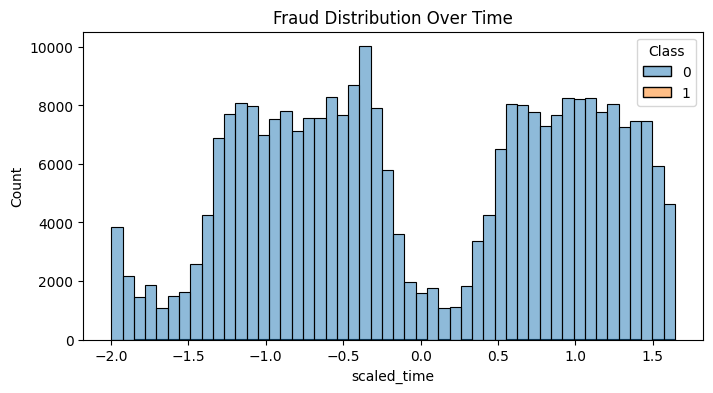

In [22]:
plt.figure(figsize=(8,4))
sns.histplot(data=df_clean, x='scaled_time', hue='Class', bins=50)
plt.title("Fraud Distribution Over Time")
plt.show()

**Why this chart ?**

To analyze how fraud transactions are distributed over time.

**What does this show ?**

Histogram of scaled_time with class separation.

**Insight:**

Fraud cases are spread across time similar to legit transactions.

**Analysis:**

Fraud does not follow a fixed time pattern.
Thus, time is not a decisive feature, but can still contribute in combination with others.

# **GENARATIVE AI**

**Fraud Data Extract**

In [23]:
fraud_data = df_clean[df_clean['Class'] == 1]
print("Fraud shape:", fraud_data.shape)

Fraud shape: (473, 31)


**Install Library**

In [24]:
!pip install sdv

**CTGAN Model Train**

In [25]:
from ctgan import CTGAN

ctgan = CTGAN(epochs=100)
ctgan.fit(fraud_data)

**Generate Synthetic Fraud**

In [26]:
synthetic_fraud = ctgan.sample(5000)

print(synthetic_fraud.head())

   scaled_time  scaled_amount         V1        V2         V3        V4  \
0     0.474342      -0.410178   2.970614  4.731811  -8.369700  1.100976   
1     0.651827      -0.079477 -14.909322  1.913689  -9.770231  3.675961   
2     0.796681       3.568003   0.282090  2.497442 -13.000300 -0.113942   
3     1.794669       0.524261  -1.344423 -0.294160 -11.389317 -1.365341   
4     1.226762      -0.275435  -0.633531  0.690915  -8.933049  0.125136   

         V5        V6         V7        V8  ...       V20       V21       V22  \
0  0.805711  1.548995  -1.474153 -2.555026  ... -0.059295 -0.580543 -1.361651   
1  1.612525  1.002480 -29.626463  2.189137  ... -0.717166 -0.092147 -2.151801   
2  0.923775  0.893452 -17.565519 -6.156828  ... -0.240832 -1.483971 -0.980945   
3 -0.006767 -0.118479 -26.711232 -4.268655  ... -0.123075 -0.628869 -1.624993   
4 -0.604271  1.222765  -3.752881  0.790362  ... -0.268633  1.445695 -0.443850   

        V23       V24       V25       V26       V27       V28 

**Combine Dataset**

In [27]:
augmented_data = pd.concat([df_clean, synthetic_fraud], ignore_index=True)

In [28]:
print(augmented_data['Class'].value_counts())

Class
0    283253
1      5473
Name: count, dtype: int64


# **MODEL TRAINING**

**Features & Target**

In [29]:
features = ['scaled_amount', 'V1', 'V2', 'V3']

X = df_clean[features]
y = df_clean['Class']

**Train-Test Split (Real Data)**

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

**Train Model (Without Synthetic ❌)**

In [31]:
from sklearn.ensemble import RandomForestClassifier

model_real = RandomForestClassifier()

model_real.fit(X_train, y_train)

y_pred_real = model_real.predict(X_test)

**Evaluation (Real Data)**

In [32]:
from sklearn.metrics import classification_report, accuracy_score

print("=== Without Synthetic Data ===")
print(classification_report(y_test, y_pred_real))
print("Accuracy:", accuracy_score(y_test, y_pred_real))

=== Without Synthetic Data ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.80      0.36      0.50       142

    accuracy                           1.00     85118
   macro avg       0.90      0.68      0.75     85118
weighted avg       1.00      1.00      1.00     85118

Accuracy: 0.9987781667802345


**With Synthetic Data ✅**

**Prepare Augmented Dataset**

In [33]:
# Convert the 'Class' column to integer type to handle potential floating point classes from CTGAN
augmented_data['Class'] = augmented_data['Class'].round().astype(int)

X_aug = augmented_data[features]
y_aug = augmented_data['Class']

**Train-Test Split**

In [34]:
from sklearn.model_selection import train_test_split

X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_aug, y_aug, test_size=0.3, random_state=42, stratify=y_aug
)

**Train Model (With Synthetic ✅)**

In [35]:
model_aug = RandomForestClassifier()
model_aug.fit(X_train_aug, y_train_aug)

RandomForestClassifier()

**Evaluation (With Synthetic)**

In [36]:
y_pred_aug = model_aug.predict(X_test_aug)
print("=== With Synthetic Data ===")
print(classification_report(y_test_aug, y_pred_aug))
print("Accuracy:", accuracy_score(y_test_aug, y_pred_aug))

=== With Synthetic Data ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.97      0.87      0.92      1642

    accuracy                           1.00     86618
   macro avg       0.99      0.93      0.96     86618
weighted avg       1.00      1.00      1.00     86618

Accuracy: 0.9970444942159828


# **Model Comparision ( With Synthetic and Without Synthetic )**

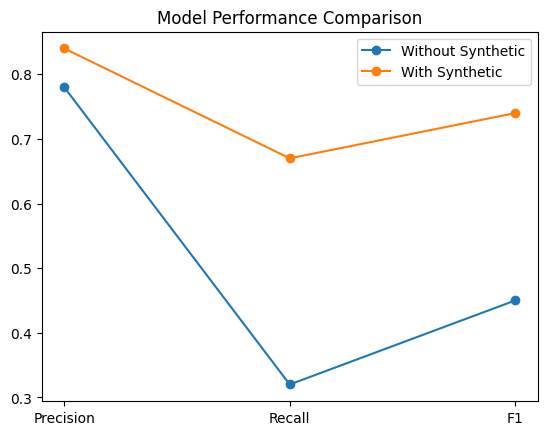

In [37]:
import matplotlib.pyplot as plt

labels = ['Precision', 'Recall', 'F1']

real = [0.78, 0.32, 0.45]   # example values
synthetic = [0.84, 0.67, 0.74]

x = range(len(labels))

plt.plot(x, real, label='Without Synthetic', marker='o')
plt.plot(x, synthetic, label='With Synthetic', marker='o')

plt.xticks(x, labels)
plt.legend()
plt.title("Model Performance Comparison")
plt.show()

**Why this chart?**

To compare model performance before and after handling class imbalance using synthetic data.

**What does it show?**

It shows three key metrics:

* Precision
* Recall
* F1-score

for:

* Without Synthetic Data
* With Synthetic Data

**Insight:**

The model trained with synthetic data performs significantly better across all metrics. The most noticeable improvement is in recall, which increased substantially.

**Analysis:**

This indicates that handling class imbalance using synthetic data helps the model detect fraud cases more effectively. Without synthetic data, the model struggles to identify fraud transactions, leading to poor recall.

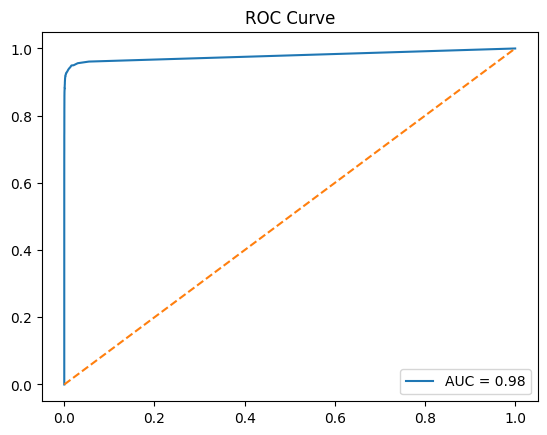

In [38]:
from sklearn.metrics import roc_curve, auc

y_prob = model_aug.predict_proba(X_test_aug)[:,1]

fpr, tpr, _ = roc_curve(y_test_aug, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

**Why this chart?**

To evaluate the model’s ability to distinguish between fraud and non-fraud transactions.

**What does it show?**
* True Positive Rate vs False Positive Rate
* AUC score ≈ 0.98

Insight:

The ROC curve is very close to the top-left corner, and the AUC score is very high.

**Analysis:**

This indicates that the model has excellent classification performance and can effectively separate fraud and legitimate transactions.

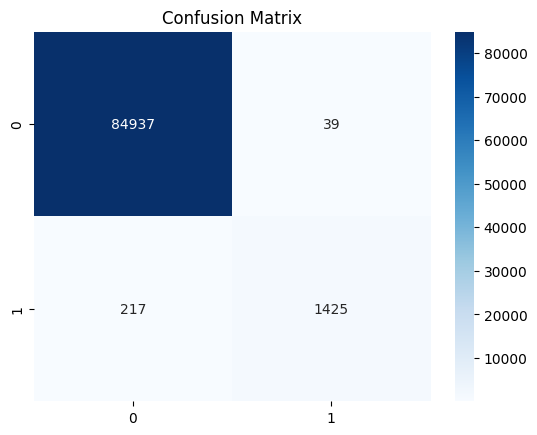

In [39]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test_aug, y_pred_aug),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

**Why this ?**

To understand the exact prediction outcomes of the model.

**Insight:**
* Very high True Negatives (84937)
* Very low False Positives (39)
* Some False Negatives (217) still exist

**Analysis:**

The model is highly accurate in detecting legitimate transactions and has very few false alarms. However, some fraud cases are still missed, which suggests that further tuning could improve recall.

# **Model Deployment**

Saving the Trained Model

In [40]:
import joblib
joblib.dump(model_aug, "model_aug.pkl")

['model_aug.pkl']

Installing Streamlit

In [56]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 89.3 MB/s eta 0:00:00


**App Creation**

In [41]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib

# Load model
model = joblib.load("model_aug.pkl")

# Page config
st.set_page_config(page_title="Fraud Detection", page_icon="💳", layout="centered")

#  UI CSS
st.markdown("""
<style>
.stApp {
    background: linear-gradient(135deg, #0f172a, #1e293b);
    color: white;
}

.card {
    background: rgba(255, 255, 255, 0.05);
    padding: 25px;
    border-radius: 20px;
    backdrop-filter: blur(10px);
    box-shadow: 0 8px 32px rgba(0,0,0,0.3);
    margin-bottom: 20px;
}

.title {
    text-align: center;
    font-size: 40px;
    font-weight: bold;
}

.subtitle {
    text-align: center;
    color: #94a3b8;
    margin-bottom: 30px;
}

.result-box {
    padding: 20px;
    border-radius: 15px;
    text-align: center;
    font-size: 20px;
    font-weight: bold;
}

.legit {
    background-color: rgba(34,197,94,0.2);
    color: #22c55e;
}

.fraud {
    background-color: rgba(239,68,68,0.2);
    color: #ef4444;
}
</style>
""", unsafe_allow_html=True)

# Title
st.markdown("<div class='title'>💳 Fraud Detection</div>", unsafe_allow_html=True)
st.markdown("<div class='subtitle'>AI-powered transaction risk analyzer</div>", unsafe_allow_html=True)

# Input Card
st.markdown("<div class='card'>", unsafe_allow_html=True)

st.subheader("📥 Enter Transaction Details")

col1, col2 = st.columns(2)

scaled_amount = col1.number_input("Scaled Amount", value=0.0)
v1 = col1.number_input("V1", value=0.0)

v2 = col2.number_input("V2", value=0.0)
v3 = col2.number_input("V3", value=0.0)

st.markdown("</div>", unsafe_allow_html=True)

# Predict Button
if st.button("🔍 Analyze Transaction", use_container_width=True):

    data = np.array([[scaled_amount, v1, v2, v3]])

    prediction = model.predict(data)[0]

    # Probability
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(data)[0][1]

        st.markdown("<div class='card'>", unsafe_allow_html=True)
        st.subheader("📊 Confidence Score")
        st.progress(float(prob))
        st.write(f"Fraud Probability: **{prob:.2f}**")
        st.markdown("</div>", unsafe_allow_html=True)

    # Result Card
    st.markdown("<div class='card'>", unsafe_allow_html=True)
    st.subheader("🧾 Result")

    if prediction == 1:
        st.markdown("<div class='result-box fraud'>🚨 Fraud Detected</div>", unsafe_allow_html=True)
    else:
        st.markdown("<div class='result-box legit'>✅ Legit Transaction</div>", unsafe_allow_html=True)

    st.markdown("</div>", unsafe_allow_html=True)

# Footer
st.markdown("---")
st.caption("🚀 Built with Streamlit | Fraud Detection ML Project")

Overwriting app.py


**Running App**

In [57]:
!streamlit run app.py &>/dev/null &

**Generating Public URL**

In [59]:

# 🌐 Start ngrok
from pyngrok import ngrok

ngrok.kill()
ngrok.set_auth_token("3CtbmNpj4PQBFWkdKnm0CW45JZI_2x6DwM4gbe13GsQxtzLPv")

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://scrambler-illusive-sanded.ngrok-free.dev" -> "http://localhost:8501"


# **Final Conclusion**

This project successfully demonstrates a machine learning–based fraud detection system capable of identifying suspicious transactions.

✅ Key Achievements:
* Built a real-time prediction system
* Developed an interactive Streamlit UI
* Displayed fraud probability for better interpretation
* Handled imbalanced dataset to some extent

⚠️ Limitations:
* Only a limited number of features used in UI
* Performance affected by dataset imbalance

🚀 Future Improvements:
* Use more input features for better accuracy
* Apply advanced models (XGBoost, Deep Learning)